# "MNIST: Distinguishing Threes from Sevens"
> Using Fastai to classify threes and sevens from the MNIST dataset.

- toc: true
- badges: true
- comments: true
- categories: [fastai, jupyter]

# Introduction

I am following along with Chapter 4 of {% cite fastbook2020 %}.

## Download dataset

In [1]:
from fastai.vision.all import *

In [2]:
#collapse-output
path = untar_data(URLs.MNIST_SAMPLE)

So what got downloaded?

In [3]:
path.ls()

(#3) [Path('/data/kaushik/.fastai/data/mnist_sample/valid'),Path('/data/kaushik/.fastai/data/mnist_sample/train'),Path('/data/kaushik/.fastai/data/mnist_sample/labels.csv')]

That huge path is a pain to look at so shorten it by setting the BASE_PATH.

In [4]:
Path.BASE_PATH = path
path.ls()

(#3) [Path('valid'),Path('train'),Path('labels.csv')]

What do we have under train?

In [5]:
(path/'train').ls()

(#2) [Path('train/3'),Path('train/7')]

What do we have under the 7?

In [6]:
(path/'train'/'7').ls().sorted()

(#6265) [Path('train/7/10002.png'),Path('train/7/1001.png'),Path('train/7/10014.png'),Path('train/7/10019.png'),Path('train/7/10039.png'),Path('train/7/10046.png'),Path('train/7/10050.png'),Path('train/7/10063.png'),Path('train/7/10077.png'),Path('train/7/10086.png')...]

We have 6,265 images of sevens. Look at one using the PIL library.

In [7]:
Image.open((path/'train'/'7').ls().sorted()[0])

In [8]:
seven_tensors = [tensor(Image.open(pic_path)).float()/255. for pic_path in (path/'train'/'7').ls().sorted()]
three_tensors = [tensor(Image.open(pic_path)).float()/255. for pic_path in (path/'train'/'3').ls().sorted()]
len(seven_tensors), len(three_tensors)

(6265, 6131)

Use Fastai convenience function _show\_image_ to display the tensor

<AxesSubplot:>

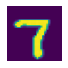

In [9]:
show_image(seven_tensors[0])

In [10]:
stacked_sevens = torch.stack(seven_tensors)
stacked_threes = torch.stack(three_tensors)
stacked_sevens.shape, stacked_threes.shape

(torch.Size([6265, 28, 28]), torch.Size([6131, 28, 28]))

# Assemble train and validation set

Assemble the training data. Each input will be a vector of 784 values.

In [11]:
train_x = torch.cat([stacked_threes, stacked_sevens]).view(-1,28*28)
train_y = tensor([1]*len(three_tensors) + [0]*len(seven_tensors)).unsqueeze(1)
train_x.shape, train_y.shape

(torch.Size([12396, 784]), torch.Size([12396, 1]))

Assemble the validation data

In [12]:
valid_7_tensors = torch.stack([tensor(Image.open(pic_path)).float()/255. for pic_path in (path/'valid'/'7').ls().sorted()])
valid_3_tensors = torch.stack([tensor(Image.open(pic_path)).float()/255. for pic_path in (path/'valid'/'3').ls().sorted()])
valid_7_tensors.shape, valid_3_tensors.shape

(torch.Size([1028, 28, 28]), torch.Size([1010, 28, 28]))

In [13]:
valid_x = torch.cat([valid_3_tensors, valid_7_tensors]).view(-1,28*28)
valid_y = tensor([1]*len(valid_3_tensors) + [0]*len(valid_7_tensors)).unsqueeze(1)
valid_x.shape, valid_y.shape

(torch.Size([2038, 784]), torch.Size([2038, 1]))

# Initialize Parameters

In [14]:
def init_params(size, std=1.0): return (torch.randn(size)*std).requires_grad_()

We have one weight for each pixel in the image. We will also have a bias term.

In [15]:
weights = init_params((28*28,1))
bias = init_params(1)
weights.shape, bias.shape

(torch.Size([784, 1]), torch.Size([1]))

# Get Predictions
Calculate the prediction for a single image

In [16]:
(train_x[0]*weights.T).sum() + bias

tensor([-11.9221], grad_fn=<AddBackward0>)

In [17]:
train_x[0].shape, weights.shape, weights.T.shape, (train_x[0]*weights).shape

(torch.Size([784]),
 torch.Size([784, 1]),
 torch.Size([1, 784]),
 torch.Size([784, 784]))

In [18]:
def linear1(xb): return xb @ weights + bias
preds = linear1(train_x)
preds

tensor([[-11.9221],
        [-15.0890],
        [ -7.4757],
        ...,
        [ -8.2333],
        [-26.8899],
        [ -3.7154]], grad_fn=<AddBackward0>)

# Compute Loss

In [19]:
def sigmoid(x): return 1./(1. + torch.exp(-x))

In [20]:
def mnist_loss(predictions, targets):
    preds = predictions.sigmoid()
    return torch.where(targets==1, 1-preds, preds).mean()

In [21]:
mnist_loss(preds, train_y)

tensor(0.4400, grad_fn=<MeanBackward0>)

# Mini-Batches

In [22]:
ds = L(enumerate(string.ascii_lowercase))
ds

(#26) [(0, 'a'),(1, 'b'),(2, 'c'),(3, 'd'),(4, 'e'),(5, 'f'),(6, 'g'),(7, 'h'),(8, 'i'),(9, 'j')...]

Each mini-batch is a tuple of some number of training examples and their corresponding labels

In [23]:
dl = DataLoader(ds,batch_size=5,shuffle=True)
first(dl), list(dl)

((tensor([13, 17, 11, 22, 12]), ('n', 'r', 'l', 'w', 'm')),
 [(tensor([23,  8, 17,  0,  3]), ('x', 'i', 'r', 'a', 'd')),
  (tensor([22,  1, 15, 11,  4]), ('w', 'b', 'p', 'l', 'e')),
  (tensor([24, 20, 16, 12, 10]), ('y', 'u', 'q', 'm', 'k')),
  (tensor([ 7, 13, 14,  5,  9]), ('h', 'n', 'o', 'f', 'j')),
  (tensor([ 2, 21, 25,  6, 18]), ('c', 'v', 'z', 'g', 's')),
  (tensor([19]), ('t',))])

In [24]:
dset = list(zip(train_x, train_y))
dl = DataLoader(dset, batch_size=256)

valid_dset = list(zip(valid_x, valid_y))
valid_dl = DataLoader(valid_dset, batch_size=256)

Simulate a batch of training examples.

In [25]:
batch = train_x[:4]
batch.shape

torch.Size([4, 784])

In [26]:
preds = linear1(batch)
preds

tensor([[-11.9221],
        [-15.0890],
        [ -7.4757],
        [  2.6071]], grad_fn=<AddBackward0>)

In [27]:
loss = mnist_loss(preds, train_y[:4])
loss

tensor(0.7670, grad_fn=<MeanBackward0>)

In [28]:
loss.backward()
weights.grad.shape, weights.grad.mean(), bias.grad

(torch.Size([784, 1]), tensor(-0.0028), tensor([-0.0161]))

# Gradient computation

In [29]:
def calc_grad(xb,yb,model):
    preds = model(xb)
    loss = mnist_loss(preds, yb)
    loss.backward()

# Train

In [30]:
def train_epoch(model, lr, params):
    for xb, yb in dl:
        calc_grad(xb,yb,model)
        for p in params:
            p.data -= p.grad*lr
            p.grad.zero_()

## Batch Accuracy

In [31]:
def batch_accuracy(preds, yb):
    preds = preds.sigmoid() #note
    correct = (preds > 0.5).float() == yb
    return correct.float().mean()

In [32]:
batch_accuracy(linear1(batch), train_y[:4])

tensor(0.2500)

In [33]:
def validate_epoch(model):
    accs = [batch_accuracy(model(xb), yb) for xb, yb in valid_dl]
    return round(torch.stack(accs).mean().item(), 4)

In [34]:
validate_epoch(linear1)

0.5512

Train one epoch

In [35]:
lr = 1

weights = init_params((28*28,1))
bias = init_params(1)
params = weights, bias

train_epoch(linear1, lr, params)
validate_epoch(linear1)

0.8062

Train multiple epochs

In [36]:
lr = 1

weights = init_params((28*28,1))
bias = init_params(1)
params = weights, bias

for i in range(20):
    train_epoch(linear1, lr, params)
    print(validate_epoch(linear1), end=' ')

0.6942 0.8666 0.9247 0.9443 0.9496 0.956 0.9604 0.9623 0.9648 0.9648 0.9667 0.9687 0.9692 0.9707 0.9716 0.9716 0.9721 0.9726 0.9731 0.9731 

# Refactor

## Replace gradient update with a home grown optimizer

In [37]:
class BasicOptim(nn.Module):
    def __init__(self,params,lr): self.params, self.lr = list(params), lr
        
    def step(self,*args,**kwargs): 
        for p in self.params: p.data -= p.grad*self.lr
            
    def zero_grad(self,*args,**kwargs): 
        for p in self.params: p.grad = None

In [38]:
lr = 1

weights = init_params((28*28,1))
bias = init_params(1)
params = weights, bias

opt = BasicOptim(params, lr)

def train_epoch(model, lr, params):
    for xb, yb in dl:
        calc_grad(xb,yb,model)
        opt.step()
        opt.zero_grad()

for i in range(20):
    train_epoch(linear1, lr, params)
    print(validate_epoch(linear1), end=' ')

0.7207 0.8887 0.9316 0.9423 0.9511 0.955 0.9594 0.9623 0.9643 0.9648 0.9653 0.9662 0.9672 0.9677 0.9682 0.9692 0.9701 0.9711 0.9711 0.9716 

## Replace init_params and linear1 with Pytorch nn.Linear

nn.Linear holds both the weights and bias and takes care of initializing the parameters.

In [39]:
linear_model = nn.Linear(28*28,1)
weights, bias = linear_model.parameters()
weights.shape, bias.shape

(torch.Size([1, 784]), torch.Size([1]))

In [40]:
lr = 1

linear_model = nn.Linear(28*28,1)
opt = BasicOptim(linear_model.parameters(), lr)

def train_epoch(model, lr, params):
    for xb, yb in dl:
        calc_grad(xb,yb,model)
        opt.step()
        opt.zero_grad()

for i in range(20):
    train_epoch(linear_model, lr, params)
    print(validate_epoch(linear_model), end=' ')

0.4932 0.8208 0.8394 0.9131 0.9346 0.9473 0.9555 0.9624 0.9653 0.9668 0.9692 0.9707 0.9736 0.9751 0.9761 0.977 0.978 0.978 0.9785 0.9785 

## Replace home grown optimizer with fastai SGD

In [41]:
lr = 1

linear_model = nn.Linear(28*28,1)
opt = SGD(linear_model.parameters(), lr)

def train_epoch(model, lr, params):
    for xb, yb in dl:
        calc_grad(xb,yb,model)
        opt.step()
        opt.zero_grad()

for i in range(20):
    train_epoch(linear_model, lr, params)
    print(validate_epoch(linear_model), end=' ')

0.4932 0.7422 0.8569 0.9165 0.9351 0.9492 0.958 0.9638 0.9658 0.9682 0.9712 0.9726 0.9746 0.9751 0.9761 0.977 0.9775 0.978 0.978 0.9785 

## Replace training loop with Fastai Learner.fit

Observe how we are able to pass in the mnist_loss and batch_accuracy functions. 

In [42]:
dls = DataLoaders(dl, valid_dl)
learn = Learner(dls, nn.Linear(28*28,1), loss_func=mnist_loss
                , opt_func=SGD
                , metrics = batch_accuracy)

In [43]:
learn.fit(20,lr=1)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.636992,0.502468,0.495584,00:00
1,0.348879,0.281710,0.730128,00:00
2,0.134591,0.154878,0.859666,00:00
3,0.063040,0.097588,0.919038,00:00
4,0.036392,0.073245,0.936212,00:00
5,0.025745,0.059577,0.950932,00:00
6,0.021219,0.050918,0.957311,00:00
7,0.019103,0.045073,0.963199,00:00
8,0.017960,0.040914,0.965653,00:00
9,0.017229,0.037820,0.968597,00:00


# Add a rectified linear unit

Plot the accuracy over the training

In [44]:
#collapse-output
simple_net = nn.Sequential(nn.Linear(28*28,30), 
                           nn.ReLU(), 
                           nn.Linear(30,1))

learn = Learner(dls, simple_net, loss_func=mnist_loss
                  , opt_func=SGD
                  , metrics=batch_accuracy)


learn.fit(n_epoch=40, lr=0.1)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.367506,0.385191,0.524534,00:00
1,0.166598,0.249851,0.783611,00:00
2,0.089627,0.122130,0.912169,00:00
3,0.056985,0.080797,0.939156,00:00
4,0.042108,0.062461,0.953876,00:00
5,0.034692,0.052266,0.964181,00:00
6,0.030548,0.045876,0.965162,00:00
7,0.027924,0.041554,0.966634,00:00
8,0.026069,0.038435,0.968106,00:00
9,0.024649,0.036068,0.969578,00:00


learn.recorder records the output from the training process. The three items recorded here are train_loss, valid_loss and batch_accuracy

In [45]:
learn.recorder.values[:2]

[(#3) [0.36750638484954834,0.3851909041404724,0.5245338678359985],
 (#3) [0.16659829020500183,0.24985098838806152,0.7836113572120667]]

Plot how the accuracy evolved during the training.

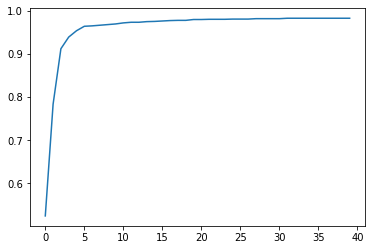

In [46]:
plt.plot(L(learn.recorder.values).itemgot(2))

The final accuracy is as below:

In [47]:
learn.recorder.values[-1][2]

0.982826292514801

# References
{% bibliography --cited %}